# 02 — Cleaning & Exploratory Data Analysis

**Goal:** clean the unified table and explore the proxy-label balance, rating skew, sentiment, and review length.

> **Weak-proxy caveat.** Label = Amazon *Verified Purchase* (purchase verification, **not** ground-truth deception). Strengthened with behavioral signals; validated against real fake-review labels in notebook 07.

In [1]:
import sys, warnings
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from src import utils, viz
config = utils.load_config()
utils.set_seeds(config["project"]["random_seed"])
viz.set_house_style()
FIG = ROOT / "reports" / "figures"; FIG.mkdir(parents=True, exist_ok=True)

In [2]:
from src import fallback_loader as fl, clean
raw = ROOT / "data" / "raw"
cats = sorted({p.name[:-9] for p in raw.glob("*.jsonl.gz") if not p.name.startswith("meta_")})
assert cats, "No data in data/raw/. Download a category (see notebook 01 / README)."
print("categories present:", cats)
df = clean.clean_reviews(pd.concat(
    [pd.DataFrame(fl.load_category(config, c, raw_dir=str(raw))) for c in cats], ignore_index=True))
print("reviews:", len(df), "| verified rate:", round((df["verified_purchase"] == True).mean(), 3))

categories present: ['Subscription_Boxes']
2026-06-09 02:56:57,240 | review_deception.fallback | INFO | Loaded 16216 reviews for category 'Subscription_Boxes' from Subscription_Boxes.jsonl.gz


2026-06-09 02:56:57,384 | review_deception.clean | INFO | Cleaned 16216 reviews (447 flagged exact-duplicate).


reviews: 16216 | verified rate: 0.88


### Proxy-label balance & rating skew

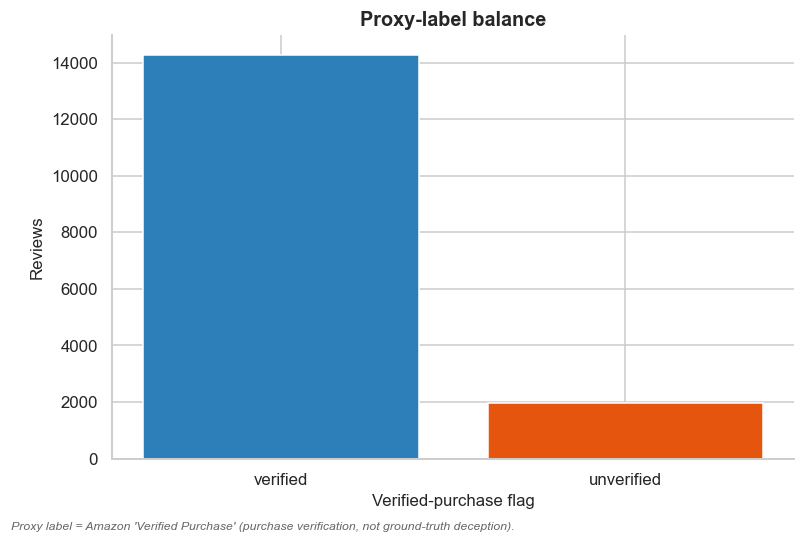

In [3]:
ax = viz.plot_class_balance(df); viz.savefig(ax, str(FIG/"02_class_balance.png")); plt.show()

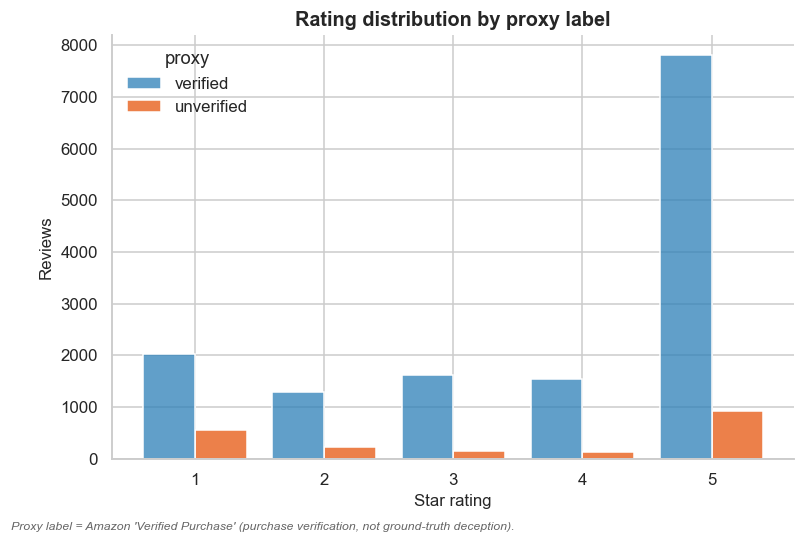

In [4]:
ax = viz.plot_rating_distribution(df); viz.savefig(ax, str(FIG/"02_rating_by_proxy.png")); plt.show()

### Sentiment & length by proxy label
Over-positivity and short, generic text are weak markers of low-effort/incentivized reviews.

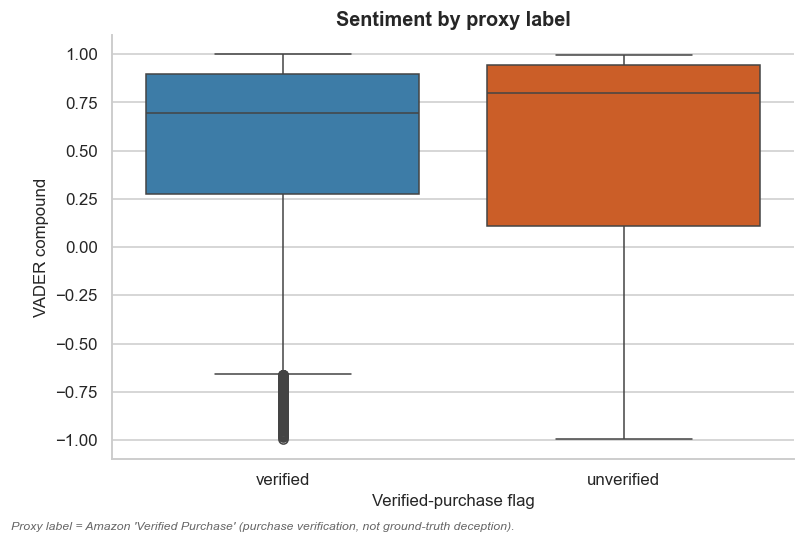

In [5]:
from src import features
feat = features.add_text_stats(features.add_sentiment(df))
ax = viz.plot_sentiment_by_group(feat); viz.savefig(ax, str(FIG/"02_sentiment_by_proxy.png")); plt.show()

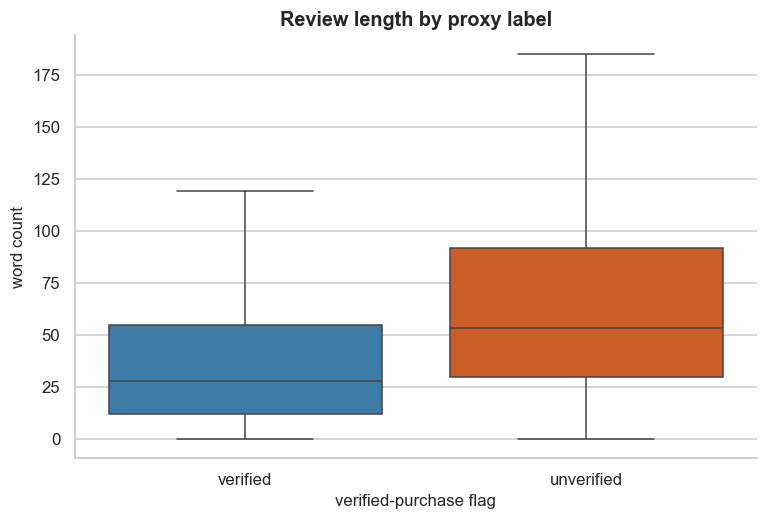

In [6]:
g = feat.assign(proxy=feat["verified_purchase"].map({True:"verified",False:"unverified"}).fillna("unknown"))
ax = sns.boxplot(data=g[g.proxy!="unknown"], x="proxy", y="word_count", hue="proxy",
                 palette=viz.TRUST_COLORS, legend=False, showfliers=False)
viz.label_axes(ax, "Review length by proxy label", "verified-purchase flag", "word count")
viz.savefig(ax, str(FIG/"02_length_by_proxy.png")); plt.show()

### Findings (real numbers)

In [7]:
print("verified rate:", round((feat.verified_purchase==True).mean(), 3))
print("median words  — verified:", int(feat.loc[feat.verified_purchase==True, "word_count"].median()),
      "| unverified:", int(feat.loc[feat.verified_purchase==False, "word_count"].median()))
print("mean sentiment — verified:", round(feat.loc[feat.verified_purchase==True, "sentiment_compound"].mean(), 3),
      "| unverified:", round(feat.loc[feat.verified_purchase==False, "sentiment_compound"].mean(), 3))
print("exact-duplicate reviews flagged:", int(df["is_exact_duplicate"].sum()))

verified rate: 0.88
median words  — verified: 28 | unverified: 53
mean sentiment — verified: 0.511 | unverified: 0.485
exact-duplicate reviews flagged: 447


**Takeaway:** read the printed contrasts above — differences in length, sentiment, and duplication between verified and unverified reviews motivate the features in notebook 03 and the classifier in notebook 04.